# Lab: Decision Trees

*This lab demonstrates the process of building, evaluating, and visualizing a Decision Tree classifier, structured according to a formal data science methodology.*

---

## 1. Business Understanding

**Scenario:** We are medical researchers compiling data for a study. We have collected data about a set of patients who all suffered from the same illness. During their course of treatment, each patient responded to one of five medications: Drug A, Drug B, Drug C, Drug X, or Drug Y.

**Business Objective:** To build a model that can predict which drug might be most appropriate for a future patient with the same illness. This will help doctors make quicker, more data-driven decisions for their patients.

---

## 2. Analytic Approach
*   **Problem Framing:** The business objective is to predict a specific category (one of five drugs) for a given patient. This is a **multi-class classification** problem.
*   **Candidate Model:** Given the need for interpretability in a medical context (doctors need to understand *why* a decision was made), a **Decision Tree** is an excellent candidate model. It provides clear, human-readable rules.
*   **Evaluation Metrics:** We will evaluate the model's performance using a **Classification Report** (which includes precision, recall, and F1-score for each class) and a **Confusion Matrix**. The overall **accuracy** should serve as a primary performance indicator if the dataset is not imbalanced.

---

## 3. Data Requirements
To build our model, we need patient data that includes demographic and health information, as well as the drug that was effective for them. The required fields are `Age`, `Sex`, `BP` (Blood Pressure), `Cholesterol`, `Na_to_K` (Sodium to Potassium ratio), and the target, `Drug`.

---

## 4. Data Collection
The data has already been collected and is available in a CSV file, which we will load into a pandas DataFrame.

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the data from the URL
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
df = pd.read_csv(path)

# Display a sample from the data
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
178,39,M,NORMAL,HIGH,15.969,drugY
55,26,F,LOW,HIGH,14.160,drugC
47,68,M,LOW,HIGH,10.291,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
147,26,F,HIGH,NORMAL,12.307,drugA



---

## 5. Data Understanding
Now, we perform Exploratory Data Analysis (EDA) to understand the data's characteristics and quality.

In [18]:
# Get a summary of the data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


> 🔍 **Initial Observation:** The dataset contains 200 entries with no missing values. The `Sex`, `BP`, `Cholesterol`, and `Drug` columns are of type `object` and will need to be converted to a numerical format for modeling.

Let's visualize the distribution of our target variable, `Drug`.

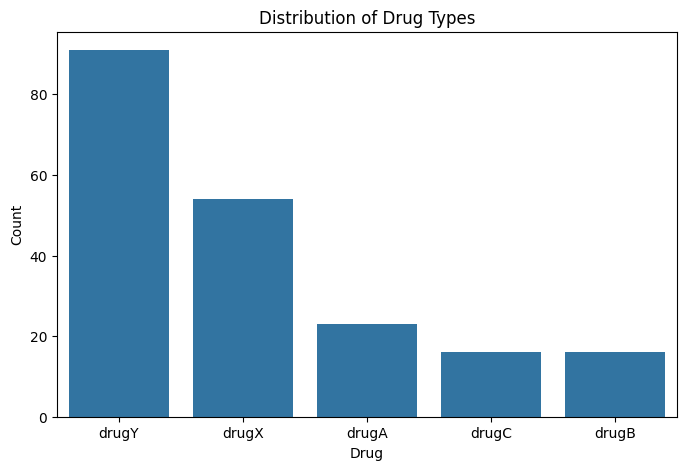

In [19]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(df, x='Drug', order=df['Drug'].value_counts().index)
plt.title('Distribution of Drug Types')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.show()

> 🔍 **Observation:** The dataset is imbalanced. `DrugY` has the most samples, while `DrugB` and `DrugC` have the fewest. This is important to keep in mind when we evaluate our model; accuracy alone might not be the best metric if the model simply learns to predict the majority class.

---

## 6. Data Preparation
First, we need to convert our categorical features into a numerical format. For tree-based models, a simple `LabelEncoder` is often sufficient.

In [20]:
# Create a LabelEncoder object
le = LabelEncoder()

# Apply the encoder to each categorical column
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])

# Display the data to see the changes
# F=0, M=1 | HIGH=0, LOW=1, NORMAL=2 | HIGH=0, NORMAL=1
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


Now, we separate the prepared data into the final feature matrix (`X`) and target vector (`y`), and then perform the train-test split.

In [21]:
# X contains our independent variables (features)
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values

# y contains our dependent variable (the target)
y = df['Drug']

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)